In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomTranslation, RandomBrightness, RandomZoom, Input
from tensorflow.keras.models import Model

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## 1. CONFIGURAÇÕES DA REDE NEURAL

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PASTA_DATASET = '/content/drive/MyDrive/Dataset_Aves_Brasil' # A pasta com as 172 subpastas
TAMANHO_IMAGEM = (224, 224) # Tamanho exigido pelo MobileNet
TAMANHO_LOTE = 32 # O modelo vai ler e aprender de 32 em 32 imagens (Batch Size)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. CARREGAMENTO DOS DADOS (TREINO E VALIDAÇÃO)

In [ ]:
# Carrega 80% das imagens para Treinamento
dataset_treino = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    validation_split=0.2, # Reserva 20%
    subset="training",    # Especifica que este é o pacote de treino
    seed=123,             # Garante que a separação aleatória seja a mesma sempre
    color_mode="rgb",     # Converte o RGBA para RGB automaticamente
    image_size=TAMANHO_IMAGEM, # Esmaga as imagens para 224x224
    batch_size=TAMANHO_LOTE
)

Found 34400 files belonging to 172 classes.
Using 27520 files for training.


In [ ]:
# Carrega os 20% restantes para Validação
dataset_validacao = tf.keras.utils.image_dataset_from_directory(
    PASTA_DATASET,
    validation_split=0.2,
    subset="validation",
    seed=123,
    color_mode="rgb",
    image_size=TAMANHO_IMAGEM,
    batch_size=TAMANHO_LOTE
)

Found 34400 files belonging to 172 classes.
Using 6880 files for validation.


In [ ]:
# Guarda o nome das espécies (ele pega o nome de cada subpasta automaticamente)
nomes_das_especies = dataset_treino.class_names
print(f"\nTotal de espécies detectadas: {len(nomes_das_especies)}")


Total de espécies detectadas: 172


## 4. OTIMIZAÇÃO DE MEMÓRIA (BOA PRÁTICA)

In [ ]:
# AUTOTUNE diz ao Keras para carregar os próximos lotes de imagens do HD para a RAM
# enquanto a placa de vídeo ainda está treinando o lote atual (evita gargalos).
AUTOTUNE = tf.data.AUTOTUNE
dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dataset_validacao = dataset_validacao.cache().prefetch(buffer_size=AUTOTUNE)

print("\nDatasets prontos, normalizados e otimizados para o MobileNet!")


Datasets prontos, normalizados e otimizados para o MobileNet!


## 5. CARREGAR A REDE PRÉ-TREINADA (Base)

In [ ]:
# 1. Define a entrada explícita
entradas = Input(shape=(224, 224, 3))

In [ ]:
# 2. Camadas de Data Augmentation (Distorções Seguras)
x = RandomTranslation(height_factor=0.0, width_factor=0.10, fill_mode='nearest')(entradas)
x = RandomBrightness(factor=0.15, value_range=(0, 255))(x)
x = RandomZoom(height_factor=0.0, width_factor=(-0.10, 0.10), fill_mode='nearest')(x)

In [ ]:
# 3 1. EfficientNetV2B1 (Mais inteligente, mesma leveza)
modelo_base = EfficientNetV2B1(input_shape=(224, 224, 3),
                               include_top=False,
                               weights='imagenet')

28456008/28456008 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Congela o modelo base para não destruir o que ele já aprendeu.
# Só treinar a nova camada que para colocar no topo.
modelo_base.trainable = False

## 6. CONSTRUIR O TOPO (A camada das aves)

In [ ]:
x = modelo_base(x)

# Achata a imagem que passou pelos filtros da rede
x = GlobalAveragePooling2D()(x)

# Adiciona um Dropout (desliga 40% dos neurônios aleatoriamente).
# Isso evita o "Overfitting"
x = Dropout(0.4)(x)

In [ ]:
# A camada final: terá exatamente 172 neurônios (len(nomes_das_especies))
# 'softmax' transforma as saídas em porcentagens (Ex: 90% Bem-te-vi, 10% João-de-barro)
numero_de_especies = len(nomes_das_especies)
camada_final = Dense(numero_de_especies, activation='softmax')(x)

In [ ]:
modelo = Model(inputs=entradas, outputs=camada_final)

## 7. COMPILAR E TREINAR

In [ ]:
print("Compilando o modelo...")
# sparse_categorical_crossentropy é a matemática perfeita para quando temos muitas categorias excludentes
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

Compilando o modelo...


In [ ]:
print("\nINICIANDO O TREINAMENTO...")
# O treinamento vai rodar 15 vezes sobre todo o dataset.
# Cada época deve aumentar a acurácia e diminuir o erro (loss).
historico = modelo.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=15
)


INICIANDO O TREINAMENTO...
Epoch 1/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 3506s 877ms/step - accuracy: 0.1253 - loss: 4.4387 - val_accuracy: 0.2743 - val_loss: 3.6841
Epoch 2/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 78s 91ms/step - accuracy: 0.2558 - loss: 3.6405 - val_accuracy: 0.3606 - val_loss: 3.1885
Epoch 3/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.3146 - loss: 3.3156 - val_accuracy: 0.4033 - val_loss: 2.9217
Epoch 4/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.3488 - loss: 3.1133 - val_accuracy: 0.4413 - val_loss: 2.7333
Epoch 5/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.3668 - loss: 2.9872 - val_accuracy: 0.4576 - val_loss: 2.6217
Epoch 6/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.3808 - loss: 2.8947 - val_accuracy: 0.4842 - val_loss: 2.5140
Epoch 7/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.3985 - loss: 2.8124 - val_accuracy: 0.4913 - val_loss: 2.4548
Epoch 8/15
860/860 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - acc

## 7.1 Treinamento Nível 2 (Fine-Tuning)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Iniciando o Fine-Tuning (Descongelamento)...")

# 1. Descongela o modelo base inteiro
modelo_base.trainable = True

# 2. Congela as primeiras 150 camadas (que identificam bordas e cores básicas)
# e deixa apenas as últimas soltas para aprender os detalhes dos espectrogramas
for layer in modelo_base.layers[:150]:
    layer.trainable = False

parada = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
reduzir_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Recompila com taxa de aprendizado bem baixinha
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

# Treina profundo por 60 épocas
historico_v3 = modelo.fit(
    dataset_treino,
    validation_data=dataset_validacao,
    epochs=60,
    callbacks=[parada, reduzir_lr]
)

Iniciando o Fine-Tuning (Descongelamento)...
Epoch 1/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 195s 193ms/step - accuracy: 0.4218 - loss: 2.6586 - val_accuracy: 0.6400 - val_loss: 1.6345 - learning_rate: 1.0000e-04
Epoch 2/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 162s 188ms/step - accuracy: 0.6072 - loss: 1.7137 - val_accuracy: 0.7140 - val_loss: 1.2971 - learning_rate: 1.0000e-04
Epoch 3/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 162s 188ms/step - accuracy: 0.6862 - loss: 1.3526 - val_accuracy: 0.7554 - val_loss: 1.1076 - learning_rate: 1.0000e-04
Epoch 4/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 162s 188ms/step - accuracy: 0.7409 - loss: 1.1132 - val_accuracy: 0.7830 - val_loss: 0.9524 - learning_rate: 1.0000e-04
Epoch 5/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 161s 188ms/step - accuracy: 0.7814 - loss: 0.9230 - val_accuracy: 0.8083 - val_loss: 0.8577 - learning_rate: 1.0000e-04
Epoch 6/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 162s 188ms/step - accuracy: 0.8104 - loss: 0.7835 - val_accuracy: 0.8250 - val_loss: 0.7830 - learning_rate: 1.0000

## 8. SALVAR O MODELO

In [ ]:
modelo.save('/content/drive/MyDrive/SabIA_1/modelo_aves_efficientnet_v2B1_filtered.keras')
print("\nModelo EfficientNet v2B1 Salvo!")


Modelo EfficientNet v2B1 Salvo!


In [ ]:
# Comprime o arquivo do modelo para poder ser usado em um app de celular

# Carrega o modelo
# modelo = tf.keras.models.load_model('/content/drive/MyDrive/SabIA_1/modelo_aves_efficientnet_v2B1_v5.keras')

print("Convertendo para TensorFlow Lite...")
# Inicializa o conversor
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)

# (Opcional, mas recomendado) Aplica otimizações para deixar o modelo ainda mais leve no celular
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Executa a conversão
modelo_tflite = converter.convert()

# Salva o arquivo pronto para ser colocado no aplicativo
caminho_tflite = '/content/drive/MyDrive/SabIA_1/modelo_aves__v2B1_filtered.tflite'
with open(caminho_tflite, 'wb') as f:
    f.write(modelo_tflite)

Convertendo para TensorFlow Lite...
Saved artifact at '/tmp/tmplyve6xvq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 172), dtype=tf.float32, name=None)
Captures:
  133327975031504: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133327975031312: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  133327975030544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133327975033808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133327975033424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133327975034000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133327975032848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133327975032656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133327975034192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133327975033616: TensorSpec(

## 9. VALIDAÇÃO

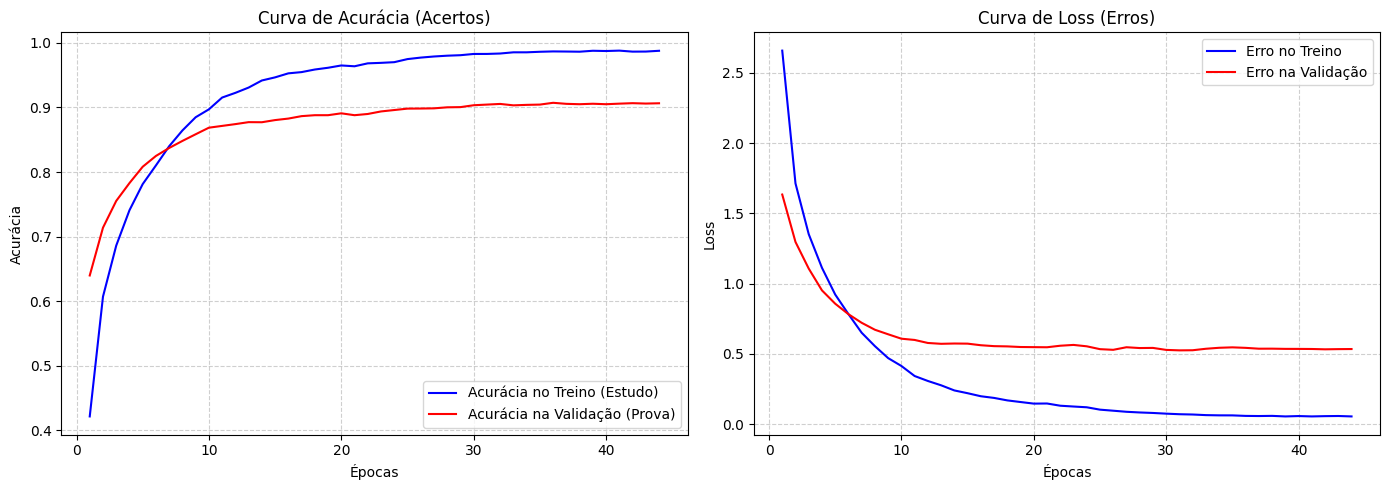

In [ ]:
# Gráfico de aprendizado

# Extrai os dados da variável 'historico' gerada no passo anterior
acc = historico_v3.history['accuracy']
val_acc = historico_v3.history['val_accuracy']
loss = historico_v3.history['loss']
val_loss = historico_v3.history['val_loss']
epocas = range(1, len(acc) + 1)

# Cria uma figura com dois gráficos lado a lado
plt.figure(figsize=(14, 5))

# Gráfico 1: Acurácia (Precisamos que a linha suba e estabilize)
plt.subplot(1, 2, 1)
plt.plot(epocas, acc, 'b-', label='Acurácia no Treino (Estudo)')
plt.plot(epocas, val_acc, 'r-', label='Acurácia na Validação (Prova)')
plt.title('Curva de Acurácia (Acertos)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Loss (Precisamos que a linha caia e aproxime de zero)
plt.subplot(1, 2, 2)
plt.plot(epocas, loss, 'b-', label='Erro no Treino')
plt.plot(epocas, val_loss, 'r-', label='Erro na Validação')
plt.title('Curva de Loss (Erros)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Matriz de confusão
print("Realizando predições no dataset de validação. Aguarde...")

y_true = []
y_pred = []

# Itera sobre todos os lotes de imagens separadas para validação
for imagens, labels in dataset_validacao:
    previsoes = modelo.predict(imagens, verbose=0)
    # Pega o índice da classe com a maior probabilidade (Ex: 99% Bem-te-vi)
    classes_previstas = np.argmax(previsoes, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(classes_previstas)

print("\n=======================================================")
print("             RELATÓRIO DE CLASSIFICAÇÃO                ")
print("=======================================================")
# Imprime as métricas completas para cada espécie
# (Ocultamos os avisos de classes com zero previsões para deixar o log limpo)
import warnings
warnings.filterwarnings('ignore')

relatorio = classification_report(y_true, y_pred, target_names=nomes_das_especies)
print(relatorio)

# ==========================================
# GERANDO A MATRIZ DE CONFUSÃO
# ==========================================
# Calcula a matriz matemática
matriz = confusion_matrix(y_true, y_pred)

# Para 216 espécies, a imagem precisa ser bem grande
# plt.figure(figsize=(20, 18))
# # Usamos uma paleta de cores 'Blues'. O vmax limita a cor para destacar os erros.
# sns.heatmap(matriz, annot=False, cmap='Blues',
#             xticklabels=nomes_das_especies,
#             yticklabels=nomes_das_especies)

# plt.title('Matriz de Confusão - Identificação de Aves', fontsize=16)
# plt.ylabel('Espécie Real', fontsize=12)
# plt.xlabel('Espécie Prevista pela IA', fontsize=12)

# # Remove os rótulos do eixo X e Y se ficarem muito poluídos (opcional)
# plt.xticks(rotation=90, fontsize=6)
# plt.yticks(fontsize=6)

# plt.show()

In [ ]:
# Pega a matriz que você já gerou no código anterior
matriz_erros = matriz.copy()

# Zera a diagonal principal (que são os acertos) para olharmos só para os erros
np.fill_diagonal(matriz_erros, 0)

print("TOP 10 CONFUSÕES DO MODELO:\n")
# Pega os índices dos maiores valores na matriz
indices_maiores_erros = np.argsort(matriz_erros, axis=None)[-20:][::-1]

for idx in indices_maiores_erros:
    linha = idx // len(nomes_das_especies)
    coluna = idx % len(nomes_das_especies)

    especie_real = nomes_das_especies[linha]
    especie_prevista = nomes_das_especies[coluna]
    quantidade_erros = matriz_erros[linha, coluna]

    print(f"O modelo achou que era {especie_prevista}, mas na verdade era {especie_real} ({quantidade_erros} vezes)")